## CHB-MIT dataset analysis

In [1]:
import mne
print(mne.__version__)

1.11.0


In [2]:
import os

chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
print(f"Checking contents of directory: {chb_01}")
try:
    for item in os.listdir(chb_01):
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{chb_01}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")


Checking contents of directory: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01
chb01-summary.txt
chb01_01.edf
chb01_02.edf
chb01_03.edf
chb01_03.edf.seizures
chb01_04.edf
chb01_04.edf.seizures
chb01_05.edf
chb01_06.edf
chb01_07.edf
chb01_08.edf
chb01_09.edf
chb01_10.edf
chb01_11.edf
chb01_12.edf
chb01_13.edf
chb01_14.edf
chb01_15.edf
chb01_15.edf.seizures
chb01_16.edf
chb01_16.edf.seizures
chb01_17.edf
chb01_18.edf
chb01_18.edf.seizures
chb01_19.edf
chb01_20.edf
chb01_21.edf
chb01_21.edf.seizures
chb01_22.edf
chb01_23.edf
chb01_24.edf
chb01_25.edf
chb01_26.edf
chb01_26.edf.seizures
chb01_27.edf
chb01_29.edf
chb01_30.edf
chb01_31.edf
chb01_32.edf
chb01_33.edf
chb01_34.edf
chb01_36.edf
chb01_37.edf
chb01_38.edf
chb01_39.edf
chb01_40.edf
chb01_41.edf
chb01_42.edf
chb01_43.edf
chb01_46.edf


In [3]:
import mne

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data
    print("\n--- Raw Info ---")
    print(raw.info)

    print("\n--- Channel Names ---")
    print(raw.ch_names[:10]) # Print first 10 channel names
    if len(raw.ch_names) > 10:
        print(f"... and {len(raw.ch_names) - 10} more channels")

    print("\n--- Data Shape (channels, samples) ---")
    print(raw.get_data().shape)

    print("\n--- Sample Frequency ---")
    print(f"{raw.info['sfreq']} Hz")


except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\gorse\AppData\Local\Temp\ipykernel_5472\2068937870.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf

--- Raw Info ---
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

--- Channel Names ---
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']
... and 13 more channels

--- Data Shape (channels, samples) ---
(23, 921600)

--- Sample Frequency ---
256.0 Hz


In [7]:
import mne
import numpy as np

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data briefly
    print(f"Channels: {raw.ch_names}")

    # --- 1. Set Channel Types Only ---
    # We define these as EEG so MNE knows how to handle the units.
    raw.set_channel_types({name: 'eeg' for name in raw.ch_names}, verbose='warning')

    # --- 2. Calculate Scaling on RAW Data ---
    # We calculate the scaling based on the raw data itself.
    data = raw.get_data()

    # Calculate peak-to-peak amplitude to find a good scale
    # This ensures the messy raw lines don't overlap too much.
    ptp_range = np.ptp(data, axis=1).max()

    # Use 1/10th of the range or 50 microvolts, whichever is larger
    scale_factor = max(50e-6, ptp_range / 10)

    print("\n--- Plotting Raw Data ---")

    # --- 3. Plot with Readable Parameters ---
    raw.plot(
        duration=30.0,                 # Show 30 seconds per window
        n_channels=len(raw.ch_names),  # Show all channels
        scalings={'eeg': scale_factor},# Apply the calculated scaling
        title='CHB-MIT chb01_01 - Raw Unfiltered Data',
        block=True,
        preload=True
    )

except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\gorse\AppData\Local\Temp\ipykernel_5472\137484222.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

--- Plotting Raw Data ---
An error occurred: BaseRaw.plot() got an unexpected keyword argument 'preload'


In [ ]:
print(raw.ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


Channels marked as bad:
[np.str_('C4-P4')]


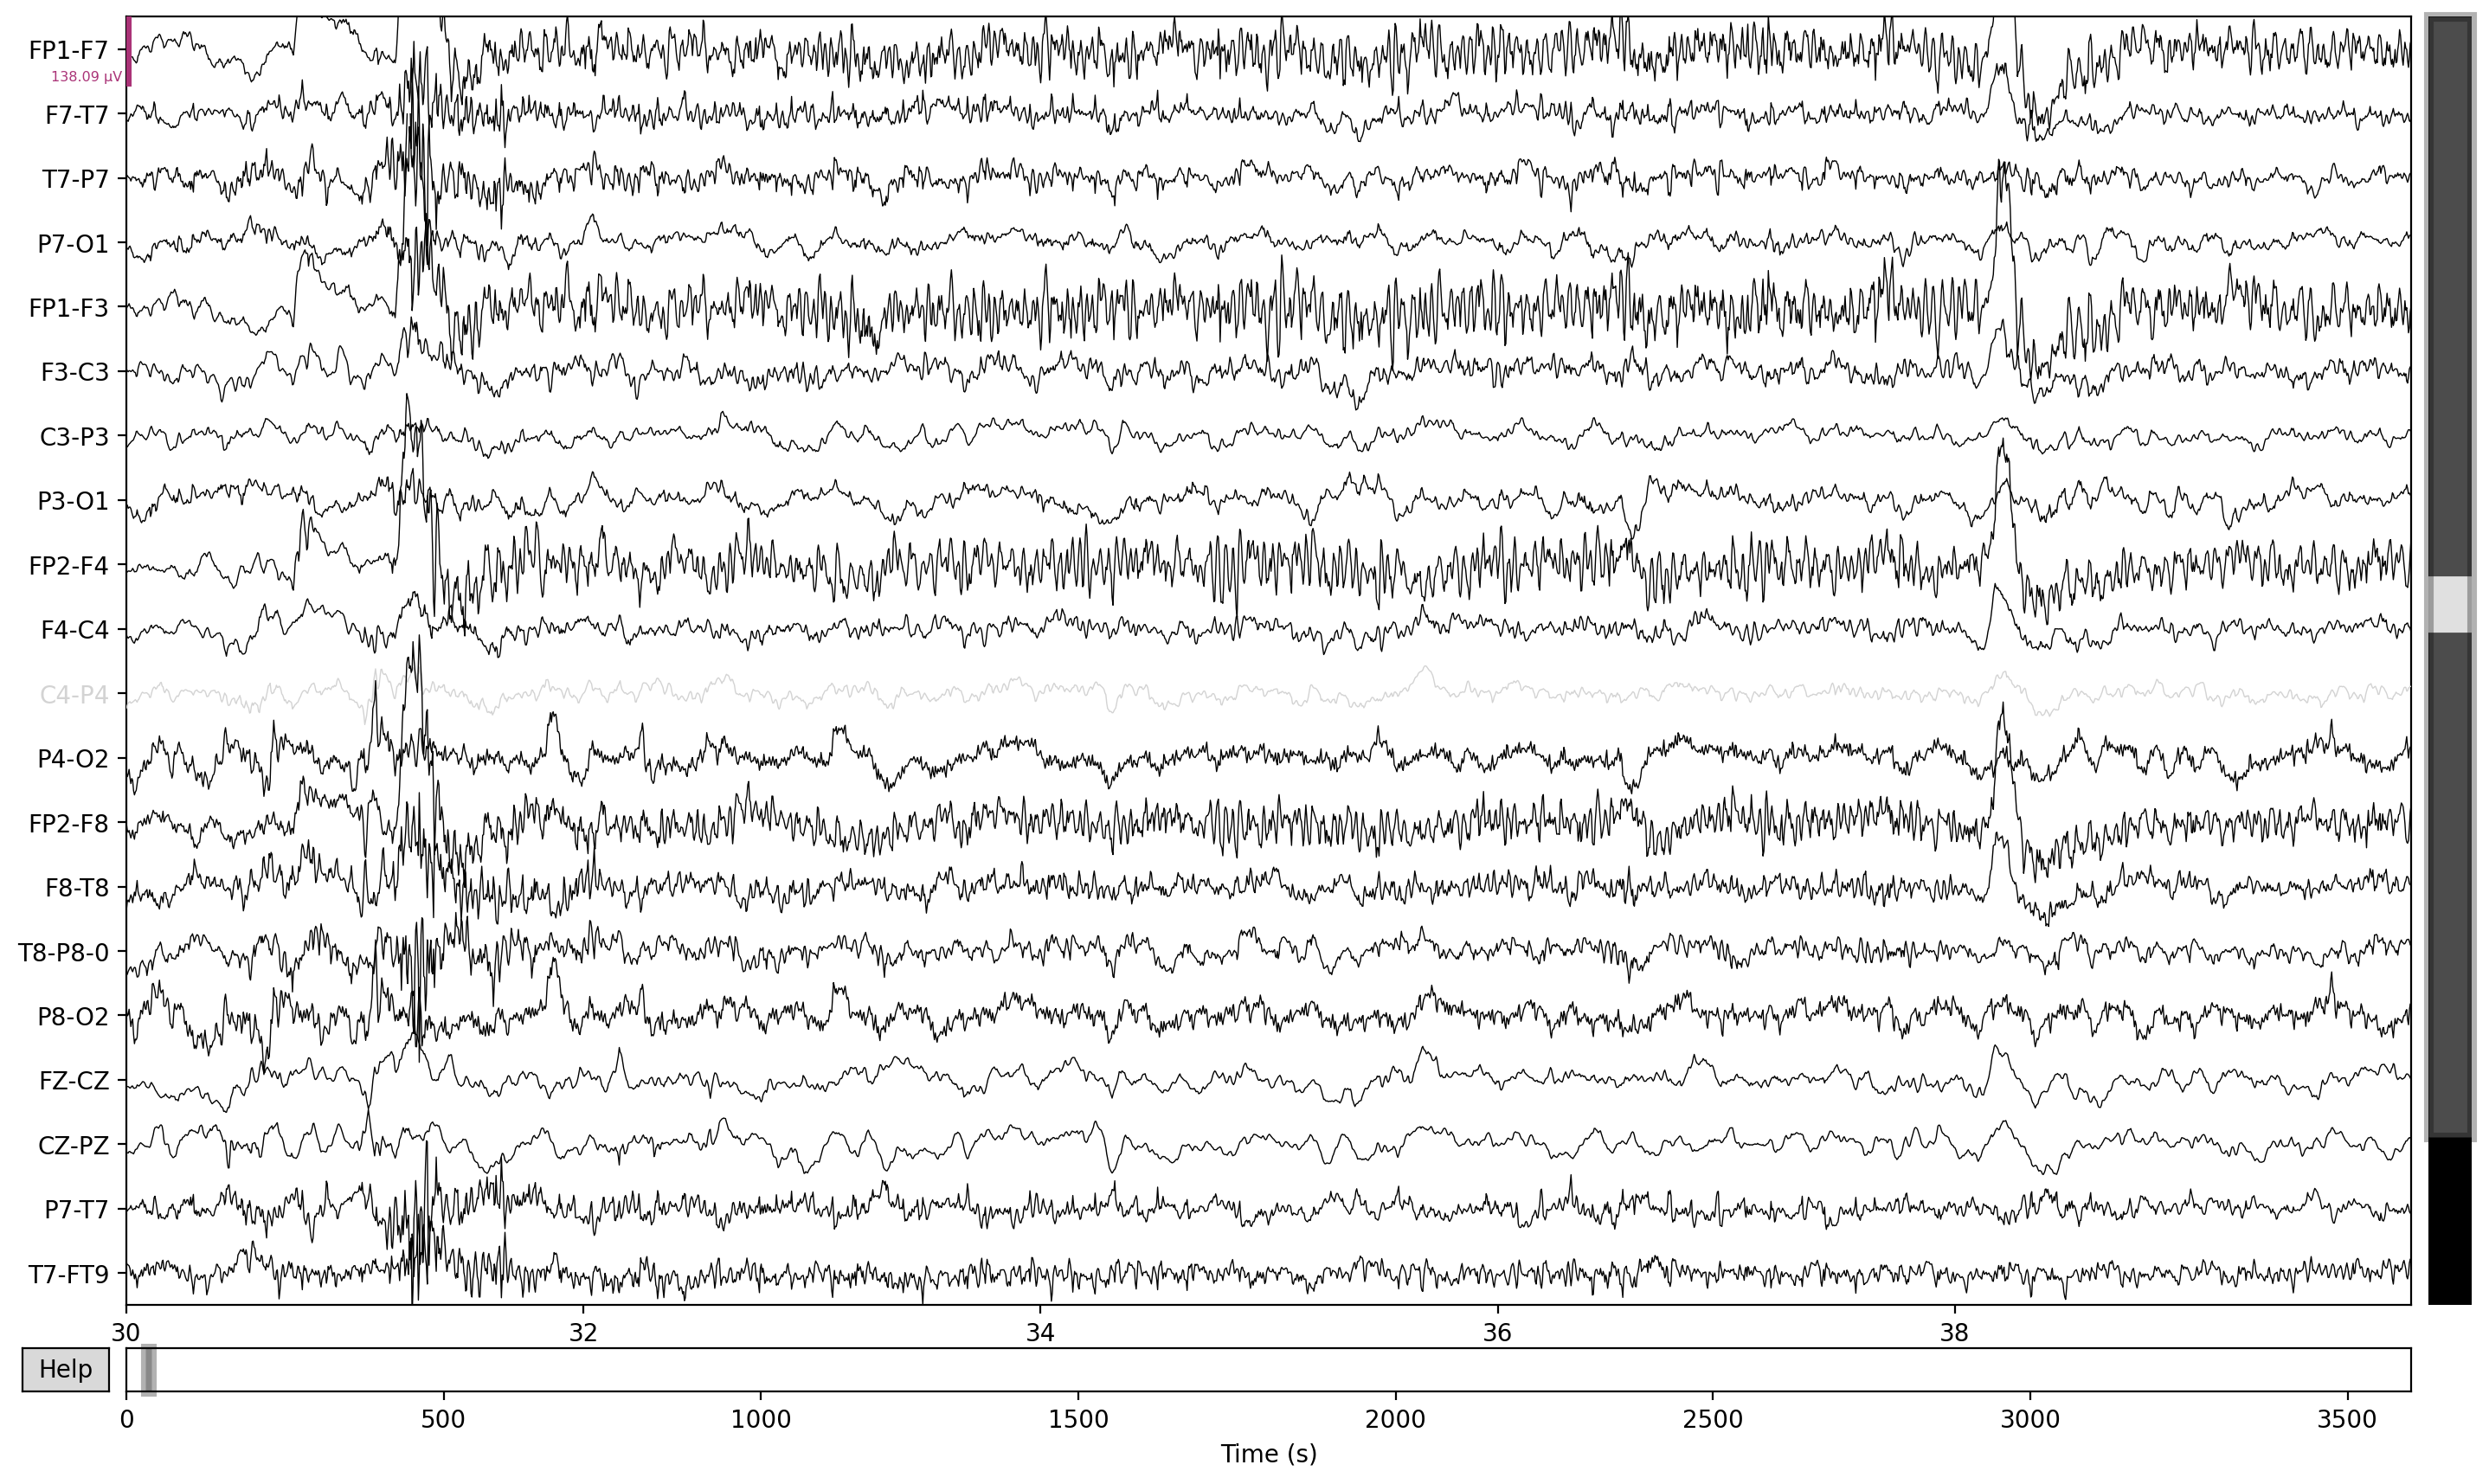

In [11]:
raw.plot(block=True)

## 'T8-P8-1' drop 

In [12]:
import os
import re
import mne
import matplotlib.pyplot as plt
import numpy as np

# Path to chb01 folder
chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
summary_file = os.path.join(chb_01, 'chb01-summary.txt')

# Parse the CHB-MIT Summary File
def parse_summary_text(summary_path):
    """
    Parses the standard chbXX-summary.txt file to extract seizure times.
    Returns a dictionary: { 'filename.edf': [(start, end), (start, end)] }
    """
    seizure_map = {}
    current_file = None

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizure_map:
                seizure_map[current_file] = []

        # Detect Seizure Times (Standard CHB format)
        if "Seizure" in line and "Start Time" in line:
            try:
                # Extract the start time
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))

                # Look ahead to the next line for End Time
                next_line = lines[i+1].strip()
                end_sec = int(re.search(r':\s*(\d+)\s*seconds', next_line).group(1))

                seizure_map[current_file].append((start_sec, end_sec))
            except (AttributeError, IndexError, ValueError):
                continue

    return seizure_map

In [13]:
# 1. Parse annotations
print(f"Parsing summary file: {summary_file}")
try:
    file_seizures = parse_summary_text(summary_file)
except FileNotFoundError:
    print("Error: chb01-summary.txt not found. Please check your chb_01 path.")
    file_seizures = {}

total_seizure_duration = 0
total_non_seizure_duration = 0

# Get list of EDF files in directory
edf_files = sorted([f for f in os.listdir(chb_01) if f.endswith('.edf')])

print(f"Processing {len(edf_files)} EDF files...")

for edf_filename in edf_files:
    edf_path = os.path.join(chb_01, edf_filename)

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')

        # Get total file duration
        edf_duration = raw.times[-1]

        # Calculate seizure duration for this specific file
        current_seizure_dur = 0
        if edf_filename in file_seizures:
            for start, end in file_seizures[edf_filename]:
                current_seizure_dur += (end - start)

        # Calculate non-seizure
        current_non_seizure_dur = edf_duration - current_seizure_dur

        # Accumulate totals
        total_seizure_duration += current_seizure_dur
        total_non_seizure_duration += current_non_seizure_dur

    except Exception as e:
        print(f"Error processing {edf_filename}: {e}")

# Plotting the Results

total_duration = total_seizure_duration + total_non_seizure_duration
seizure_pct = (total_seizure_duration / total_duration) * 100
non_seizure_pct = (total_non_seizure_duration / total_duration) * 100

print(f"\n--- Results for Patient chb01 ---")
print(f"Total Seizure: {total_seizure_duration:.2f}s ({seizure_pct:.2f}%)")
print(f"Total Non-Seizure: {total_non_seizure_duration:.2f}s ({non_seizure_pct:.2f}%)")

# Create Pie Chart
labels = ['Seizure', 'Non-Seizure']
percentages = [seizure_pct, non_seizure_pct]
colors = ['#ff9999', '#66b3ff'] # Red for seizure, Blue for normal

plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Patient chb01: Seizure vs Non-Seizure Duration')
plt.axis('equal')
plt.show()

Parsing summary file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01-summary.txt
Processing 42 EDF files...

--- Results for Patient chb01 ---
Total Seizure: 442.00s (0.30%)
Total Non-Seizure: 145545.84s (99.70%)


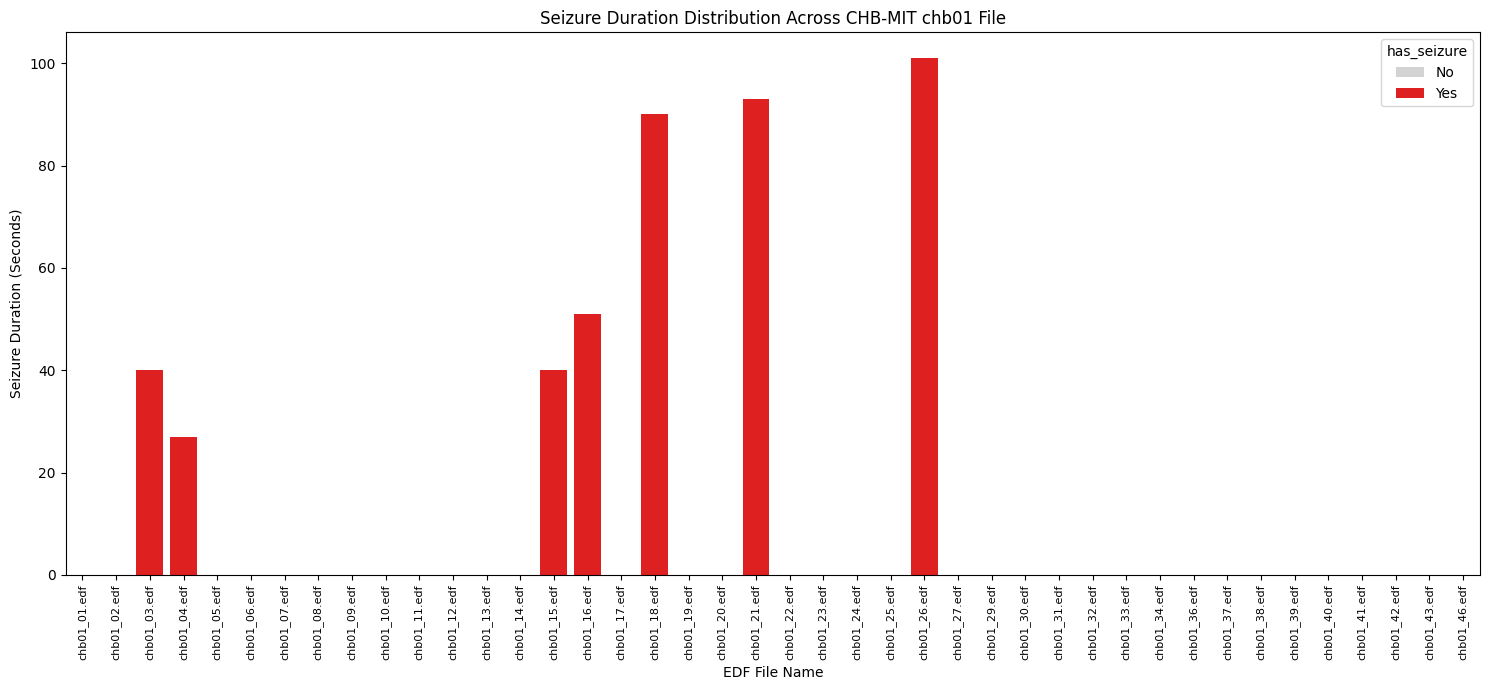

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
seizure_data_per_file = []
for edf_filename, seizure_list in file_seizures.items():
    current_seizure_duration = sum(end - start for start, end in seizure_list)
    seizure_data_per_file.append({
        'filename': edf_filename,
        'seizure_duration_seconds': current_seizure_duration,
        'has_seizure': 'Yes' if current_seizure_duration > 0 else 'No'
    })

df_seizure_distribution = pd.DataFrame(seizure_data_per_file)

# Sort by filename for chronological order
df_seizure_distribution = df_seizure_distribution.sort_values(by='filename').reset_index(drop=True)

plt.figure(figsize=(15, 7))
sns.barplot(
    x='filename',
    y='seizure_duration_seconds',
    hue='has_seizure',
    palette={'Yes': 'red', 'No': 'lightgray'},
    data=df_seizure_distribution,
    dodge=False
)
plt.title('Seizure Duration Distribution Across CHB-MIT chb01 File')
plt.xlabel('EDF File Name')
plt.ylabel('Seizure Duration (Seconds)')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

Processing 24 patients...
Plotting 198 seizure events...


C:\Users\gorse\AppData\Local\Temp\ipykernel_13732\3794748041.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


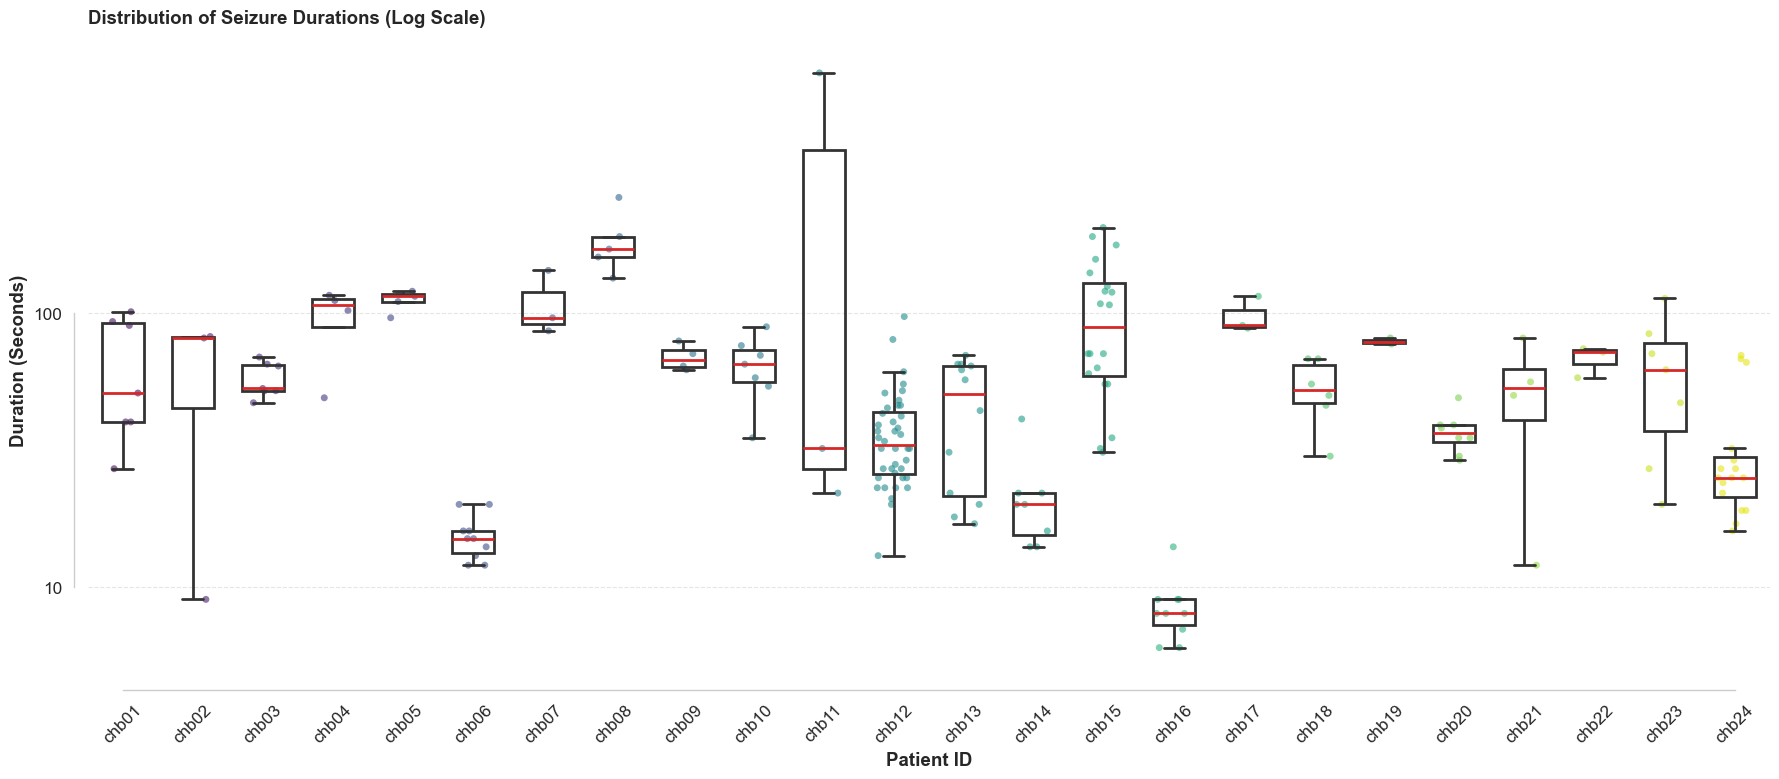

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne
import re
from matplotlib.ticker import ScalarFormatter

# =========================================================
# 1. DEFINE THE PARSER FUNCTION (Missing Piece)
# =========================================================
def parse_summary_text(summary_path):
    """
    Parses a CHB-MIT summary text file to extract seizure start/end times.
    Returns a dict: {'filename.edf': [(start_sec, end_sec), ...]}
    """
    seizures = {}
    current_file = None
    
    with open(summary_path, 'r') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        line = line.strip()
        
        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizures:
                seizures[current_file] = []
        
        # Detect Seizure Times
        # Format usually: "Seizure 1 Start Time: 123 seconds"
        elif "Seizure" in line and "Start Time" in line:
            try:
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))
                # Look ahead for end time (usually next line or two)
                end_line = lines[i+1].strip()
                if "End Time" in end_line:
                    end_sec = int(re.search(r':\s*(\d+)\s*seconds', end_line).group(1))
                    seizures[current_file].append((start_sec, end_sec))
            except (AttributeError, ValueError, IndexError):
                continue
                
    return seizures

# =========================================================
# 2. DATA COLLECTION
# =========================================================
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

all_seizure_durations = []

# Get patient directories
try:
    patient_dirs = sorted([d for d in os.listdir(base_dir)
                           if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])
except FileNotFoundError:
    print(f"Error: Directory not found at {base_dir}")
    patient_dirs = []

if patient_dirs:
    print(f"Processing {len(patient_dirs)} patients...")

    for patient_id in patient_dirs:
        patient_dir = os.path.join(base_dir, patient_id)
        summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")
        
        # 1. Parse annotations
        if os.path.exists(summary_file):
            file_seizures = parse_summary_text(summary_file)
        else:
            print(f"Summary file missing for {patient_id}")
            continue

        # 2. Process seizure data
        for edf_filename, seizure_list in file_seizures.items():
            for start, end in seizure_list:
                duration = end - start
                
                # Filter out negative or zero durations (sanity check)
                if duration > 0:
                    all_seizure_durations.append({
                        'Patient ID': patient_id,
                        'File': edf_filename,
                        'Seizure Duration (s)': duration
                    })

# =========================================================
# 3. VISUALIZATION
# =========================================================

# Create DataFrame
df_seizures = pd.DataFrame(all_seizure_durations)

if not df_seizures.empty:
    print(f"Plotting {len(df_seizures)} seizure events...")
    
    patient_order = sorted(df_seizures['Patient ID'].unique())

    # Set theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
    plt.figure(figsize=(18, 8))
    ax1 = plt.gca()

    # 1. Strip Plot (Individual Dots)
    sns.stripplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        palette='viridis',
        size=5,
        alpha=0.6,
        jitter=0.25,
        zorder=0
    )

    # 2. Box Plot (Statistics)
    sns.boxplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        showfliers=False,
        width=0.6,
        linewidth=2,
        boxprops=dict(facecolor="none", edgecolor="#333333", zorder=1),
        whiskerprops=dict(color="#333333", linewidth=2),
        capprops=dict(color="#333333", linewidth=2),
        medianprops=dict(color="#D62828", linewidth=2)
    )

    # Scaling and Styling
    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(ScalarFormatter())
    
    ax1.set_title('Distribution of Seizure Durations (Log Scale)', loc='left', fontweight='bold', pad=15)
    ax1.set_ylabel('Duration (Seconds)', fontweight='bold')
    ax1.set_xlabel('Patient ID', fontweight='bold')
    
    ax1.grid(axis='y', linestyle='--', alpha=0.5, which='major')
    ax1.tick_params(axis='x', rotation=45)

    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    plt.show()

Processing 24 patients...


C:\Users\gorse\AppData\Local\Temp\ipykernel_13732\3797865692.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


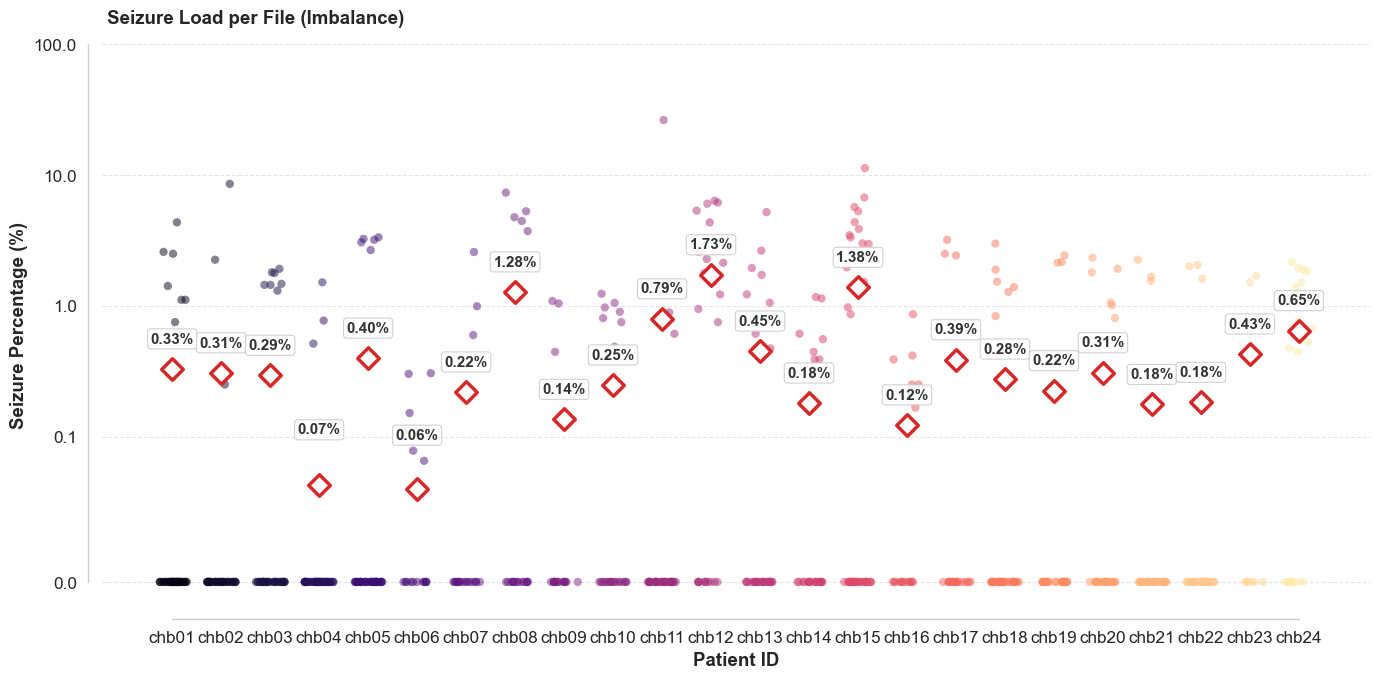

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne
import re
from matplotlib.ticker import ScalarFormatter

# ---------------------------------------------------------
# 1. SETUP AND DATA LOADING
# ---------------------------------------------------------
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get patient directories
try:
    patient_dirs = sorted([d for d in os.listdir(base_dir)
                           if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])
except FileNotFoundError:
    print(f"Directory not found: {base_dir}")
    patient_dirs = []

data_durations = []   
data_percentages = [] 

if patient_dirs:
    print(f"Processing {len(patient_dirs)} patients...")

    for patient_id in patient_dirs:
        patient_dir = os.path.join(base_dir, patient_id)
        summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

        try:
            # Check if parse_summary_text exists, otherwise skip or define it
            if 'parse_summary_text' in globals():
                file_seizures = parse_summary_text(summary_file) 
            else:
                # Placeholder if function is missing in this context
                continue 
        except Exception:
            continue

        edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])
        
        for edf_filename in edf_files:
            edf_path = os.path.join(patient_dir, edf_filename)

            try:
                # Read EDF header
                raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
                edf_duration = raw.times[-1]
                
                file_seizure_dur_total = 0
                
                # --- COLLECT DATA ---
                if edf_filename in file_seizures:
                    for start, end in file_seizures[edf_filename]:
                        duration = end - start
                        file_seizure_dur_total += duration
                        
                        data_durations.append({
                            'Patient ID': patient_id,
                            'Seizure Duration (s)': duration
                        })

                if edf_duration > 0:
                    pct = (file_seizure_dur_total / edf_duration) * 100
                    data_percentages.append({
                        'Patient ID': patient_id,
                        'Seizure Percentage': pct
                    })

            except Exception as e:
                # print(f"  Error {edf_filename}: {e}")
                continue

# ---------------------------------------------------------
# 2. PLOTTING (The Fix)
# ---------------------------------------------------------

# FIX 1: Create the correct DataFrame for percentages
df_files = pd.DataFrame(data_percentages)

if not df_files.empty:
    
    # Ensure consistent order
    patient_order = sorted(df_files['Patient ID'].unique())

    # Create the figure
    plt.figure(figsize=(14, 7))
    ax2 = plt.gca() # Get current axis

    # FIX 2: Use df_files here (not df_seizures)
    sns.stripplot(
        data=df_files,
        x='Patient ID',
        y='Seizure Percentage',
        ax=ax2,
        order=patient_order,
        palette='magma',      
        size=6,
        alpha=0.5,
        jitter=0.3,
        zorder=1
    )

    # 2. Add Mean Markers
    # FIX 3: Use df_files here too
    pct_means = df_files.groupby('Patient ID')['Seizure Percentage'].mean().reindex(patient_order)
    
    ax2.scatter(
        range(len(patient_order)), pct_means,
        color='white', s=120, marker='D', zorder=3, edgecolors='#D62828', linewidth=2.5, label='Mean %'
    )
    
    # 3. Add Text Labels for Means
    for x, val in enumerate(pct_means):
        if pd.notna(val):
            ax2.text(
                x, val * 1.5 if val > 0 else 0.1, 
                f"{val:.2f}%", 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#333',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='#ccc', boxstyle='round,pad=0.2')
            )

    # 4. SymLog Scale
    ax2.set_yscale('symlog', linthresh=0.1) 
    ax2.set_yticks([0, 0.1, 1, 10, 100])
    ax2.get_yaxis().set_major_formatter(ScalarFormatter())
    
    ax2.set_title(' Seizure Load per File (Imbalance)', loc='left', fontweight='bold', pad=15)
    ax2.set_ylabel('Seizure Percentage (%)', fontweight='bold')
    ax2.set_xlabel('Patient ID', fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    sns.despine(offset=10, trim=True)
    plt.tight_layout()
    plt.show()

Found 24 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']

Processing chb01...
  Seizures: 7, Interictal hours: 40.43
Processing chb02...
  Seizures: 3, Interictal hours: 35.22
Processing chb03...
  Seizures: 7, Interictal hours: 37.89
Processing chb04...
  Seizures: 4, Interictal hours: 155.96
Processing chb05...
  Seizures: 5, Interictal hours: 38.85
Processing chb06...
  Seizures: 10, Interictal hours: 66.69
Processing chb07...
  Seizures: 3, Interictal hours: 66.96
Processing chb08...
  Seizures: 5, Interictal hours: 19.75
Processing chb09...
  Seizures: 4, Interictal hours: 67.79
Processing chb10...
  Seizures: 7, Interictal hours: 49.90
Processing chb11...
  Seizures: 3, Interictal hours: 34.57
Processing chb12...
  Seizures: 40, Interictal hours: 23.28
Processing chb13...
  Seizures: 12, Interictal hours

C:\Users\gorse\AppData\Local\Temp\ipykernel_13732\210426727.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorse\AppData\Local\Temp\ipykernel_13732\210426727.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


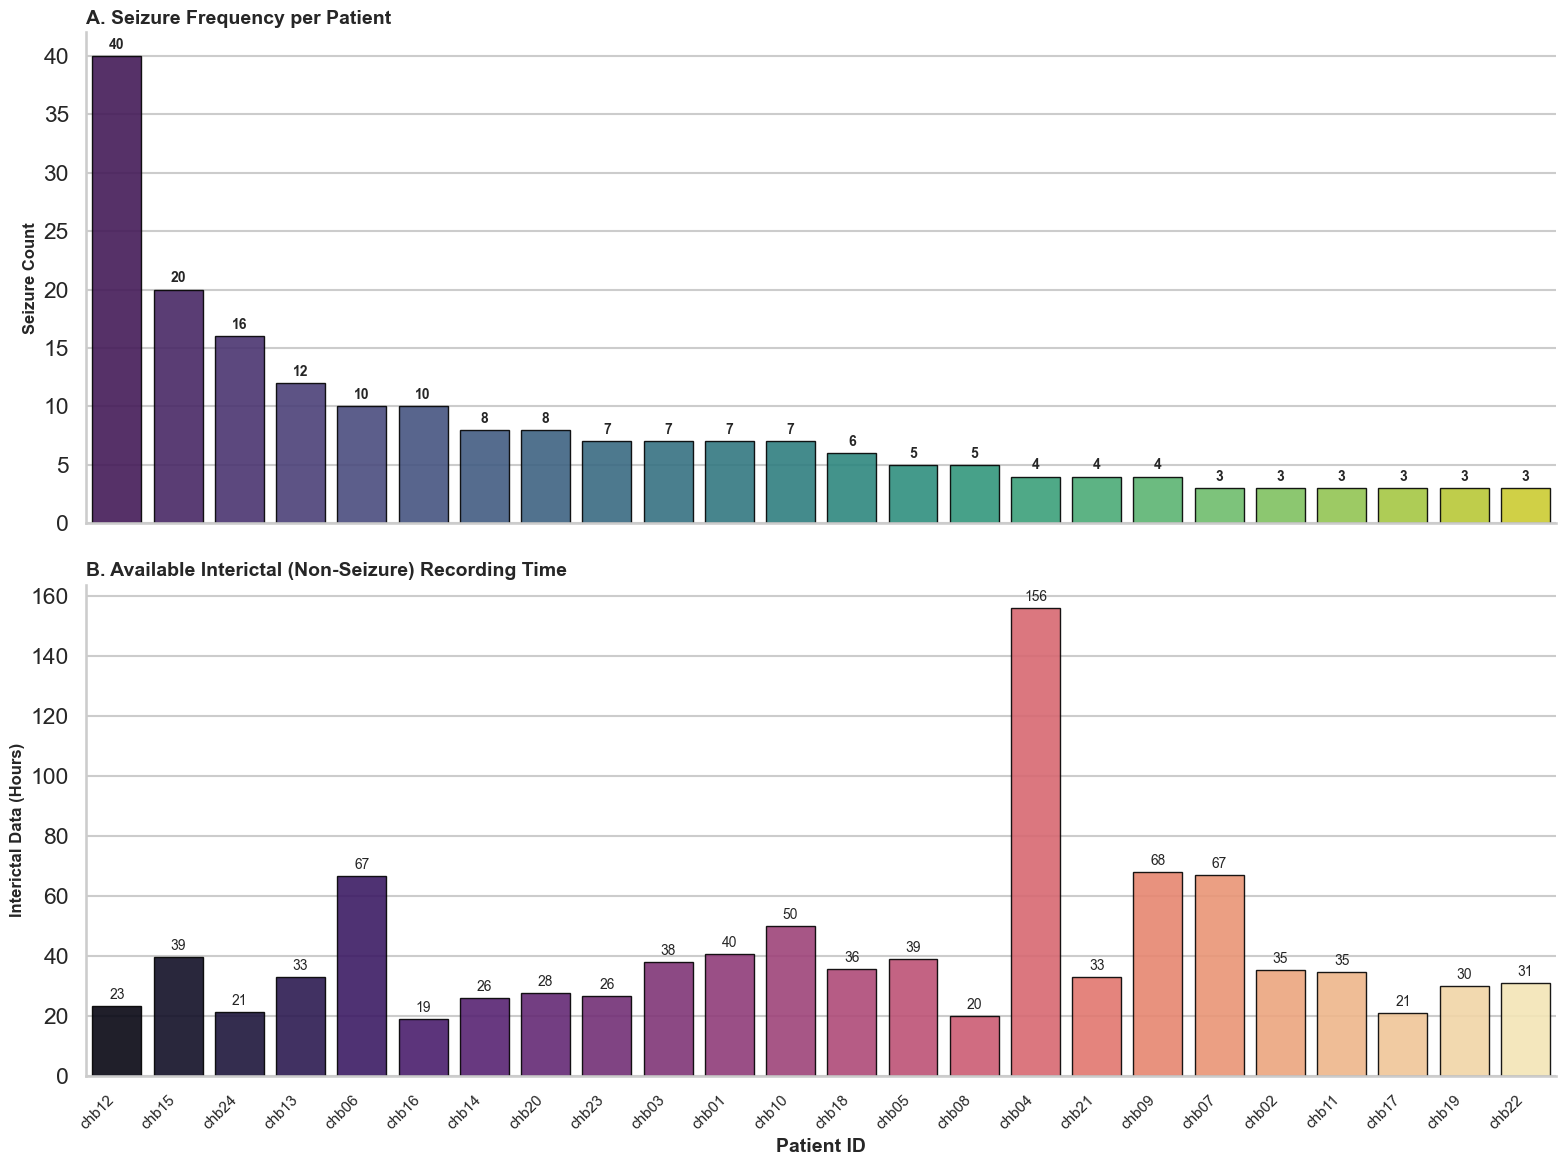

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne

# ---------------------------------------------------------
# 1. SETUP AND DATA LOADING
# ---------------------------------------------------------
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get all patient directories
patient_dirs = sorted([d for d in os.listdir(base_dir)
                       if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])

print(f"Found {len(patient_dirs)} patients: {patient_dirs}\n")

# Store characteristics for each patient
patient_characteristics = {}

for patient_id in patient_dirs:
    patient_dir = os.path.join(base_dir, patient_id)
    summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")
    
    print(f"Processing {patient_id}...")

    # Parse annotations
    try:
        # Assuming parse_summary_text is defined elsewhere
        file_seizures = parse_summary_text(summary_file)

    except FileNotFoundError:
        print(f"  Warning: Summary file not found for {patient_id}, skipping.")
        continue
    except Exception as e:
        print(f"  Error parsing summary for {patient_id}: {e}")
        continue

    # Count number of seizures
    num_seizures = sum(len(seizures) for seizures in file_seizures.values())

    # Calculate total interictal hours (non-seizure time)
    total_duration = 0
    total_seizure_duration = 0

    edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

    for edf_filename in edf_files:
        edf_path = os.path.join(patient_dir, edf_filename)

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
            file_duration = raw.times[-1]
            total_duration += file_duration

            # Calculate seizure duration for this file
            if edf_filename in file_seizures:
                for start, end in file_seizures[edf_filename]:
                    total_seizure_duration += (end - start)

        except Exception as e:
            print(f"  Error processing {edf_filename}: {e}")

    # Calculate interictal time (non-seizure) in hours
    interictal_duration = total_duration - total_seizure_duration
    interictal_hours = interictal_duration / 3600  # Convert seconds to hours
    
    patient_characteristics[patient_id] = {
        'num_seizures': num_seizures,
        'interictal_hours': interictal_hours
    }

    print(f"  Seizures: {num_seizures}, Interictal hours: {interictal_hours:.2f}")

print(f"\n{'='*60}")
print(f"Successfully processed {len(patient_characteristics)} patients\n")

# ---------------------------------------------------------
# 2. PLOTTING LOGIC
# ---------------------------------------------------------
if patient_characteristics:
    # 1. Convert to DataFrame for easier handling
    df = pd.DataFrame.from_dict(patient_characteristics, orient='index')
    df.index.name = 'PatientID'
    df.reset_index(inplace=True)
    
    # OPTIONAL: Sort by Number of Seizures to reveal patterns
    df = df.sort_values(by='num_seizures', ascending=False)

    # 2. Setup Figure with 2 vertical subplots sharing the X-axis
    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

    # -----------------------------------------------------
    # TOP PLOT: Number of Seizures (The "Event" Count)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='num_seizures', 
        ax=ax1, 
        palette='viridis',     # Scientific, colorblind-friendly
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels on top of bars
    for container in ax1.containers:
        ax1.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    ax1.set_ylabel('Seizure Count', fontweight='bold', fontsize=12)
    ax1.set_title('A. Seizure Frequency per Patient', loc='left', fontweight='bold', fontsize=14)
    ax1.grid(axis='x', alpha=0) # Clean up vertical grids
    
    # -----------------------------------------------------
    # BOTTOM PLOT: Interictal Hours (The "Background" Data)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='interictal_hours', 
        ax=ax2, 
        palette='magma',       # Distinct palette to differentiate from top plot
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

    ax2.set_ylabel('Interictal Data (Hours)', fontweight='bold', fontsize=12)
    ax2.set_title('B. Available Interictal (Non-Seizure) Recording Time', loc='left', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Patient ID', fontweight='bold', fontsize=14)
    ax2.grid(axis='x', alpha=0)

    # Rotate x-labels for better reading
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    # Remove top/right spines for a cleaner look
    sns.despine()

    plt.tight_layout()
    plt.show()

else:
    print("No patient data found to plot.")

## Plotting spectral density of continuous data

---

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\.venv\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


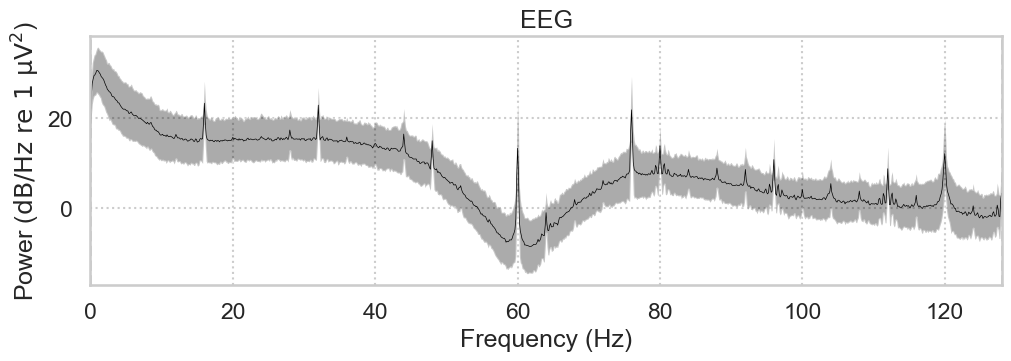

In [33]:
# Use the loaded Raw object `raw` (not the path string `chb_01`) to compute / plot PSD.
raw.plot_psd(average=True, picks='eeg', exclude='bads');

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


C:\Users\gorse\AppData\Local\Temp\ipykernel_13732\812031043.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spectrum.plot(average=False, picks="data", exclude="bads", amplitude=False, spatial_colors=True)
c:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\.venv\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\.venv\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


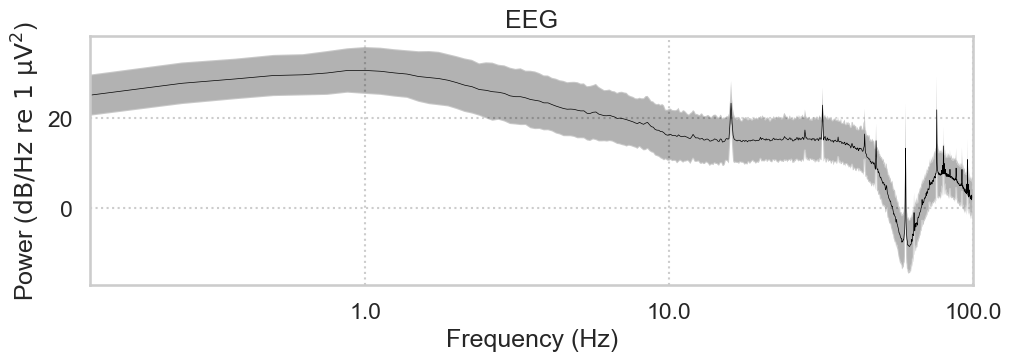

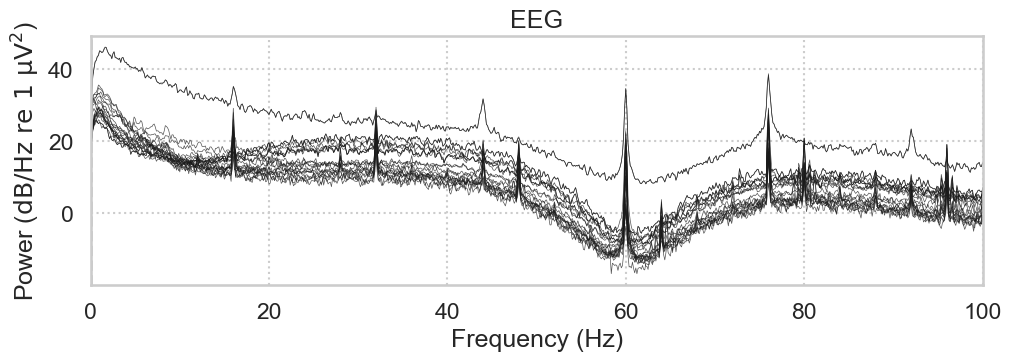

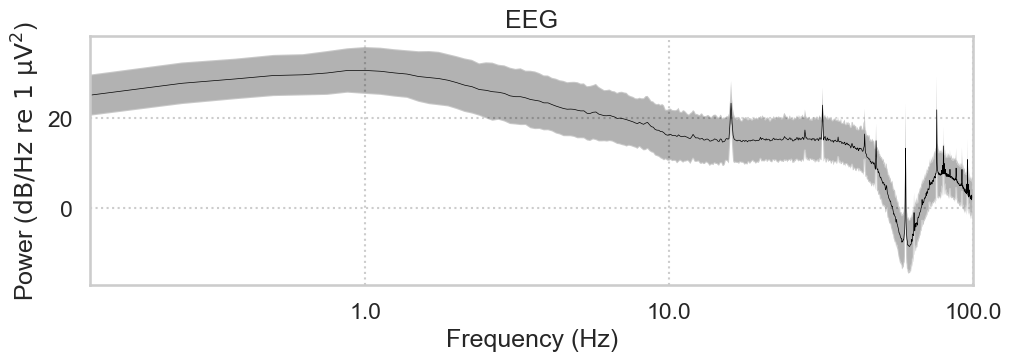

In [34]:
# 1. Compute PSD up to a relevant max frequency (100Hz to see the drop-off)
spectrum = raw.compute_psd(fmax=100)

# 2. Plot without averaging first to see if specific channels are noisy
spectrum.plot(average=False, picks="data", exclude="bads", amplitude=False, spatial_colors=True)

# 3. Plot with a log scale on X if you need to inspect low-freq drift closely
spectrum.plot(average=True, xscale="log")

## Auditing for Preprocessing

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path


In [15]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [21]:
import sys
import os
from pathlib import Path

# 1. Get the current working directory
current_dir = Path(os.getcwd())

# 2. Find the Project Root
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez")

src_path = project_root / "src"

# 4. Insert 'src' into sys.path
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f" Added 'src' to Path: {src_path}")

# 5. Verification Check
try:
    from eeg.preprocessing import CHBMITPreprocessor
    print(" SUCCESS: 'eeg.preprocessing' found and imported!")
except ModuleNotFoundError as e:
    print(f" FAIL: {e}")

 Added 'src' to Path: c:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\src
 SUCCESS: 'eeg.preprocessing' found and imported!


In [13]:
from eeg.preprocessing import CHBMITPreprocessor
from pathlib import Path
import mne

# # 1. Define paths as variables first (Use Path objects for easier handling)
raw_data_dir = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit")
processed_dir = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\preprocessed")

# 2. Initialize the Preprocessor using those variables
preprocessor = CHBMITPreprocessor(
    base_dir=raw_data_dir,
    output_dir=processed_dir
 )

# 3. Find the raw file correctly
# We look inside 'raw_data_dir' (and likely the subject subfolder like 'chb01')
subject_id = "chb01"  # Define which subject you are testing
subject_folder = raw_data_dir / subject_id

# Check if the folder exists to avoid errors
if not subject_folder.exists():
    print(f" Error: Could not find folder: {subject_folder}")
else:
    edf_files = sorted(subject_folder.glob("*.edf"))
    
    if edf_files:
        edf_path = edf_files[0]
        print(f"Found file: {edf_path.name}")
        
       # Load the raw data
        raw_before = mne.io.read_raw_edf(
            edf_path,
            preload=True,
            verbose="error"
        )
        print("Raw data loaded successfully!")
    else:
     print(f" No .edf files found in {subject_folder}")



Found file: chb01_01.edf
Raw data loaded successfully!


In [37]:
# --- STEP 1: PREPROCESS (Continuous Data) ---
# Apply the cleaning steps sequentially
raw_clean = preprocessor.canonical_channels(raw_before)
raw_clean = preprocessor.apply_filtering(raw_clean)
raw_clean = preprocessor.downsample(raw_clean)

# --- VISUAL CHECK 1: Did the filtering work? ---
# Plot the CONTINUOUS clean signal. 
# This is what you usually want to "analyse if preprocessing worked".
print("Plotting Continuous Preprocessed Data...")
raw_clean.plot(
    title="Continuous Preprocessed Signal (Clean)", 
    duration=30.0,  # Show 30 seconds at a time
    n_channels=22,  # Show 20 channels
    scalings='auto', 
    block=True      # Pause script so you can see the plot
)

# --- STEP 2: EPOCHING (Segmentation) ---
# Now we test if the windowing logic works.
print("Extracting Epochs...")

epochs = preprocessor.extract_epochs_mne(
    raw_clean,
    seizure_times=[],         # No seizures for this test
    global_seizure_times=[],
    cumulative_start_time=0.0
)

# --- VISUAL CHECK 2: Did the epoching work? ---
if epochs is None or len(epochs) == 0:
    print("Result: No valid epochs generated (Check your Interictal thresholds).")
else:
    print(f"Result: Generated {len(epochs)} epochs.")
    print(f"Classes found: {epochs.event_id}")

    # Plot whatever epochs we found (likely only Interictal)
    # We do NOT ask for 'Seizure' specifically, to avoid the ValueError
    epochs.plot(
        n_epochs=5, 
        title="Epoched Data (Snapshots)", 
        scalings='auto', 
        block=True
    )
# Now plot the preprocessed EEG data
raw_after.plot(title="After Preprocessing (Canonical Montage)")

DEBUG: Initial channels (22): ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8']
DEBUG: Picking 22 indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
SUCCESS: Final channels (22): ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8']
Plotting Continuous Preprocessed Data...
Channels marked as bad:
none
Extracting Epochs...


ValueError: No matching events found for Seizure (event id 1)

In [ ]:
# Initialize the processor
preprocessor = CHBMITPreprocessor(raw_data_dir, processed_dir)

# Process the raw object
try:
    raw_preprocessed = preprocessor.canonical_channels(raw)
    print("\nSUCCESS!")
    print(f"Final Channel Count: {len(raw_preprocessed.ch_names)}")
    print(f"Channels: {raw_preprocessed.ch_names}")
except Exception as e:
    print(f"\nERROR: {e}")


ERROR: name 'raw' is not defined


In [24]:
print(raw_before)
print(len(raw_before.ch_names))
print(raw_before.info["sfreq"])

<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>
23
256.0


In [26]:
def plot_psd(raw, title, fmax=70):
    psd = raw.compute_psd(fmax=fmax, verbose="error")
    psd.plot(
        average=True,
        spatial_colors=False,
        show=False
    )
    plt.title(title)
    plt.show()


In [27]:
plot_psd(raw_before, "Before preprocessing (raw EDF)")

Plotting power spectral density (dB=True).


In [39]:
from eeg.preprocessing import CHBMITPreprocessor
# 1. Create a copy so we don't overwrite raw_before
raw_after = raw_before.copy()

raw_after.CHBMITPreprocessor(raw_data_dir, processed_dir)

raw_after.plot()

AttributeError: 'RawEDF' object has no attribute 'CHBMITPreprocessor'

In [52]:
def plot_psd(raw_after, title, fmax=60):
    psd = raw_after.compute_psd(fmax=fmax, verbose="error")
    psd.plot(
        average=True,
        spatial_colors=False,
        show=False
    )
    plt.title(title)
    plt.show()


Plotting power spectral density (dB=True).


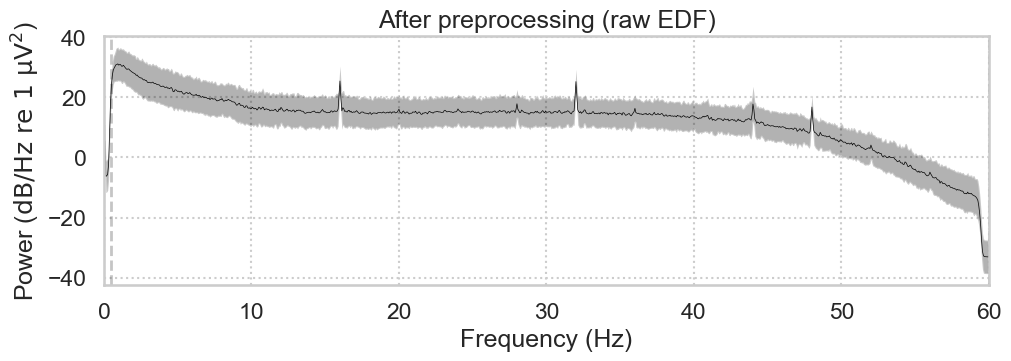

In [53]:
plot_psd(raw_after, "After preprocessing (raw EDF)")

In [54]:
print(raw_after.ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8']


Total Raw Channels:       23
Total Processed Channels: 22
 Dropped Channels (2): ['T8-P8-0', 'T8-P8-1']


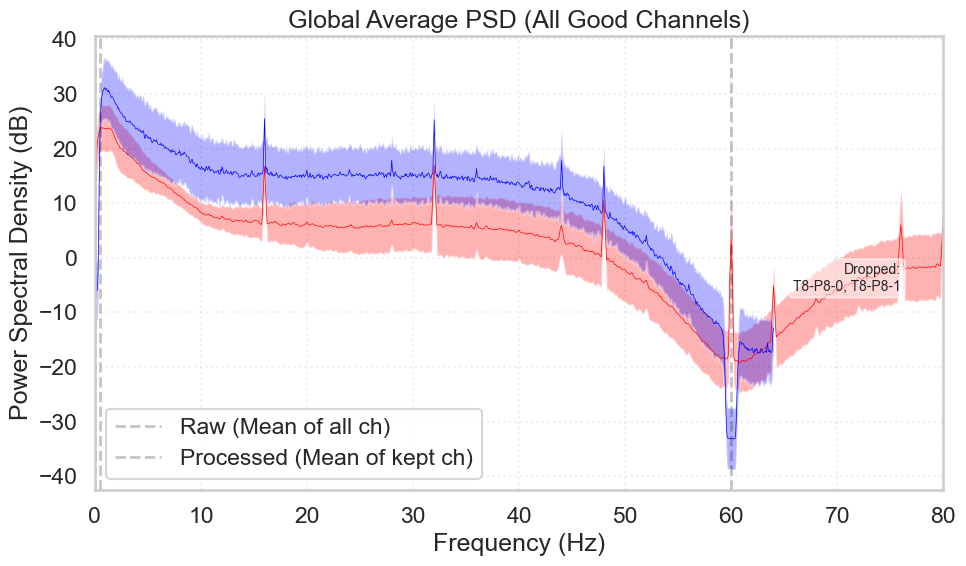

In [55]:
import matplotlib.pyplot as plt
import mne
import numpy as np

# --- 1. Settings ---
mne.set_log_level("ERROR") 

# --- 2. Identify Dropped Channels ---
ch_raw = set(raw_before.ch_names)
ch_proc = set(raw_after.ch_names)

# The difference between the sets are the dropped channels
dropped_channels = list(ch_raw - ch_proc)
kept_channels = list(ch_proc)

print("="*40)
print(f"Total Raw Channels:       {len(ch_raw)}")
print(f"Total Processed Channels: {len(ch_proc)}")
print(f" Dropped Channels ({len(dropped_channels)}): {dropped_channels}")
print("="*40)

# --- 3. Visualization (Global Average) ---
fig, ax = plt.subplots(figsize=(10, 6))

# A. Compute PSD for ALL channels
#    - Raw: Up to 80Hz to see the noise spikes
#    - Processed: Up to 64Hz (Nyquist limit for 128Hz sampling)
psd_before = raw_before.compute_psd(fmax=80)
psd_after = raw_after.compute_psd(fmax=64)

# B. Plot the AVERAGE across all channels
#    average=True collapses all channels into one thick line (the mean)
#    This represents the overall quality of the dataset
psd_before.plot(axes=ax, color='red', average=True, show=False)
psd_after.plot(axes=ax, color='blue', average=True, show=False)

# C. Formatting
ax.set_title("Global Average PSD (All Good Channels)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (dB)")
ax.legend(["Raw (Mean of all ch)", "Processed (Mean of kept ch)"])
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 80)

# Add a text box listing dropped channels on the plot for your reference
if dropped_channels:
    text_str = f"Dropped:\n{', '.join(dropped_channels)}"
    # Place text box in top right
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(0.95, 0.5, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

In [6]:
print("Number of channels:", len(raw_after.ch_names))

NameError: name 'raw_after' is not defined

In [57]:
print("Channel order:")
for i, ch in enumerate(raw_after.ch_names):
    print(i, ch)

Channel order:
0 FP1-F7
1 F7-T7
2 T7-P7
3 P7-O1
4 FP1-F3
5 F3-C3
6 C3-P3
7 P3-O1
8 FP2-F4
9 F4-C4
10 C4-P4
11 P4-O2
12 FP2-F8
13 F8-T8
14 T8-P8
15 P8-O2
16 FZ-CZ
17 CZ-PZ
18 P7-T7
19 T7-FT9
20 FT9-FT10
21 FT10-T8


In [58]:
data = raw_after.get_data()
print("Data shape:", data.shape)

Data shape: (22, 136576)


In [59]:
print(raw_after)
print("sfreq:", raw_after.info["sfreq"])
print("n_times:", raw_after.n_times)
print("duration (s):", raw_after.n_times / raw_after.info["sfreq"])

<RawEDF | chb24_22.edf, 22 x 136576 (1067.0 s), ~22.9 MiB, data loaded>
sfreq: 128.0
n_times: 136576
duration (s): 1067.0


In [60]:
print(f"Detected bad channels: {bad_channels_list}")

Detected bad channels: []


Visualizing Window #100


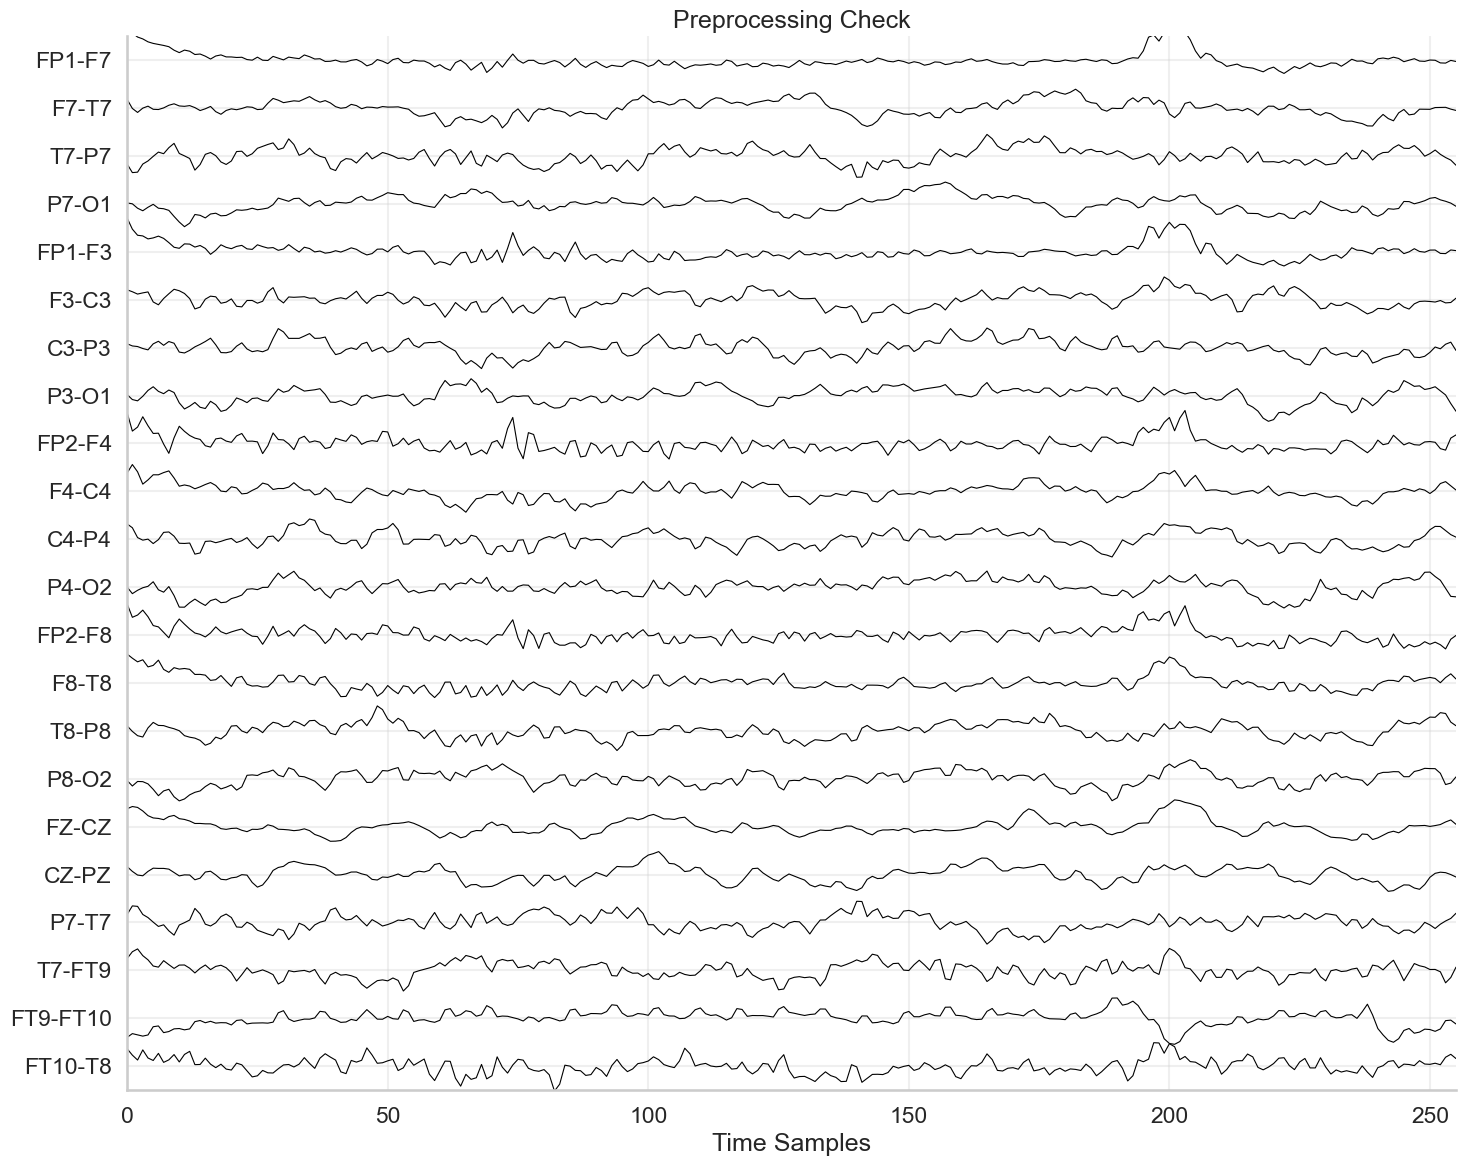

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Setup Paths
project_root = Path("..").resolve() 
data_dir = project_root / "data" / "preprocessed" / "chb01" 

if not data_dir.exists():
    print("Error: Data directory not found.")
else:
    files = list(data_dir.glob("*.npz"))
    target_file = files[0]
    
    try:
        with np.load(target_file, allow_pickle=True) as data:
            windows = data['2s']
            channels = data['channel_names']
            
            idx = 100 
            
            if idx < len(windows):
                print(f"Visualizing Window #{idx}")
                
                sample_data = windows[idx]
                avg_amplitude = np.mean(np.ptp(sample_data, axis=1))
                spacing = avg_amplitude * 1.1  
                
                # Setup Plot
                plt.figure(figsize=(15, 12))
                
                # Arrays to store tick locations
                yticks = []
                
                n_channels = len(channels)
                for i in range(n_channels):
                    # Position calculation remains the same
                    position = (n_channels - 1 - i) * spacing
                    
                    # Plot signal
                    plt.plot(sample_data[i] + position, color='black', linewidth=0.8)
                    yticks.append(position)

                plt.title(f"Preprocessing Check")
                plt.xlabel("Time Samples")
                plt.yticks(yticks, channels)
                plt.tick_params(axis='y', pad=2) 
                plt.margins(x=0, y=0.01)
                plt.ylim(yticks[-1] - (spacing * 0.5), yticks[0] + (spacing * 0.5))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
            else:
                print("File is too short to plot window #100.")

    except Exception as e:
        print(f"Error loading file: {e}")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
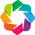

Loading: chb01_01.npz
Visualizing windows 100-120 (5120 samples)


:Overlay
   .FP1-F7   :Curve   [time]   (amplitude)
   .F7-T7    :Curve   [time]   (amplitude)
   .T7-P7    :Curve   [time]   (amplitude)
   .P7-O1    :Curve   [time]   (amplitude)
   .FP1-F3   :Curve   [time]   (amplitude)
   .F3-C3    :Curve   [time]   (amplitude)
   .C3-P3    :Curve   [time]   (amplitude)
   .P3-O1    :Curve   [time]   (amplitude)
   .FP2-F4   :Curve   [time]   (amplitude)
   .F4-C4    :Curve   [time]   (amplitude)
   .C4-P4    :Curve   [time]   (amplitude)
   .P4-O2    :Curve   [time]   (amplitude)
   .FP2-F8   :Curve   [time]   (amplitude)
   .F8-T8    :Curve   [time]   (amplitude)
   .T8-P8    :Curve   [time]   (amplitude)
   .P8-O2    :Curve   [time]   (amplitude)
   .FZ-CZ    :Curve   [time]   (amplitude)
   .CZ-PZ    :Curve   [time]   (amplitude)
   .P7-T7    :Curve   [time]   (amplitude)
   .T7-FT9   :Curve   [time]   (amplitude)
   .FT9-FT10 :Curve   [time]   (amplitude)
   .FT10-T8  :Curve   [time]   (amplitude)

In [68]:
import numpy as np
import pandas as pd
import holoviews as hv
from holoviews import opts
from pathlib import Path

# Initialize HoloViews with Bokeh backend
hv.extension('bokeh')

# 1. Setup Paths
project_root = Path("..").resolve()
data_dir = project_root / "data" / "preprocessed" / "chb01"

if not data_dir.exists():
    print("Error: Data directory not found.")
else:
    files = list(data_dir.glob("*.npz"))
    
    if not files:
        print("No .npz files found in the directory.")
    else:
        target_file = files[0] # Loading the first file
        print(f"Loading: {target_file.name}")

        try:
            with np.load(target_file, allow_pickle=True) as data:
                windows = data['2s']
                channels = data['channel_names']
                
                # Parameters for visualization
                start_idx = 100
                end_idx = 120
                
                # Check if we have enough data
                if start_idx < len(windows):
                    # Stitch the selected windows together to create a continuous signal
                    # Shape: (n_channels, n_samples * number_of_windows)
                    selected_data = np.concatenate(windows[start_idx:end_idx], axis=1)
                    
                    print(f"Visualizing windows {start_idx}-{end_idx} ({selected_data.shape[1]} samples)")

                    fs = 128  # Ensure this matches your data's sampling rate
                    n_samples = selected_data.shape[1]
                    time_seconds = np.arange(n_samples) / fs

                    # Create DataFrame: Columns = Channels, Index = Time
                    df = pd.DataFrame(selected_data.T, columns=channels)
                    df['time'] = time_seconds
                    df = df.set_index('time')

                    # --- STEP B: DEFINE DIMENSIONS ---
                    time_dim = hv.Dimension("time", unit="s")

                    # --- STEP C: CREATE CURVES DICTIONARY ---
                    curves = {}
                    for col in df.columns:
                        # Create a dimension for this specific channel
                        col_dim = hv.Dimension(col, label='amplitude', unit="µV")
                        
                        # Create the Curve element
                        curve = hv.Curve(df, time_dim, col_dim, group='EEG', label=col)
                        
                        # Apply subcoordinate_y options (The "Stacked" look)
                        curves[col] = curve.opts(
                            subcoordinate_y=True,
                            subcoordinate_scale=3, # Controls overlap between channels
                            color="black",
                            line_width=1,
                            tools=['xwheel_zoom', 'hover'],
                            active_tools=['xwheel_zoom'] # Enable scroll to zoom time by default
                        )

                    # Combine all curves into one Overlay
                    curves_overlay = hv.Overlay(curves, kdims=[time_dim, 'Channel'])
                    
                    # Apply global visual options
                    plot = curves_overlay.opts(
                        ylabel="Channel",
                        show_legend=False,
                        min_height=600,
                        responsive=True,
                        title=f"Multichannel EEG: Windows {start_idx}-{end_idx}",
                        padding=0
                    )
                    
                    display(plot) 

                else:
                    print("File is too short for the selected index.")

        except Exception as e:
            print(f"Error processing file: {e}")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
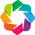

Searching files for seizure activity...
Found seizure in file: chb01_03.npz
Detected Sampling Rate: 128 Hz
Preparing Snapshot: Windows 1493 to 1523
Seizure Duration: 40 seconds (Time: 2996s - 3036s)


:Overlay
   .VSpan.I                                     :VSpan   [x,y]
   .FP1_hyphen_minus_F7.FP1_hyphen_minus_F7     :Curve   [time]   (amplitude)
   .F7_hyphen_minus_T7.F7_hyphen_minus_T7       :Curve   [time]   (amplitude)
   .T7_hyphen_minus_P7.T7_hyphen_minus_P7       :Curve   [time]   (amplitude)
   .P7_hyphen_minus_O1.P7_hyphen_minus_O1       :Curve   [time]   (amplitude)
   .FP1_hyphen_minus_F3.FP1_hyphen_minus_F3     :Curve   [time]   (amplitude)
   .F3_hyphen_minus_C3.F3_hyphen_minus_C3       :Curve   [time]   (amplitude)
   .C3_hyphen_minus_P3.C3_hyphen_minus_P3       :Curve   [time]   (amplitude)
   .P3_hyphen_minus_O1.P3_hyphen_minus_O1       :Curve   [time]   (amplitude)
   .FP2_hyphen_minus_F4.FP2_hyphen_minus_F4     :Curve   [time]   (amplitude)
   .F4_hyphen_minus_C4.F4_hyphen_minus_C4       :Curve   [time]   (amplitude)
   .C4_hyphen_minus_P4.C4_hyphen_minus_P4       :Curve   [time]   (amplitude)
   .P4_hyphen_minus_O2.P4_hyphen_minus_O2       :Curve   [time]   (amplitude)
   .FP2_hyphen_minus_F8.FP2_hyphen_minus_F8     :Curve   [time]   (amplitude)
   .F8_hyphen_minus_T8.F8_hyphen_minus_T8       :Curve   [time]   (amplitude)
   .T8_hyphen_minus_P8.T8_hyphen_minus_P8       :Curve   [time]   (amplitude)
   .P8_hyphen_minus_O2.P8_hyphen_minus_O2       :Curve   [time]   (amplitude)
   .FZ_hyphen_minus_CZ.FZ_hyphen_minus_CZ       :Curve   [time]   (amplitude)
   .CZ_hyphen_minus_PZ.CZ_hyphen_minus_PZ       :Curve   [time]   (amplitude)
   .P7_hyphen_minus_T7.P7_hyphen_minus_T7       :Curve   [time]   (amplitude)
   .T7_hyphen_minus_FT9.T7_hyphen_minus_FT9     :Curve   [time]   (amplitude)
   .FT9_hyphen_minus_FT10.FT9_hyphen_minus_FT10 :Curve   [time]   (amplitude)
   .FT10_hyphen_minus_T8.FT10_hyphen_minus_T8   :Curve   [time]   (amplitude)

In [72]:
import numpy as np
import pandas as pd
import holoviews as hv
from holoviews import opts
from pathlib import Path

# Initialize HoloViews with Bokeh backend
hv.extension('bokeh')

# 1. Setup Paths
project_root = Path("..").resolve()
data_dir = project_root / "data" / "preprocessed" / "chb01"

if not data_dir.exists():
    print("Error: Data directory not found.")
else:
    files = list(data_dir.glob("*.npz"))
    
    target_file = None
    seizure_indices = []
    
    print("Searching files for seizure activity...")
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as check_data:
                if 'labels' in check_data:
                    lbls = check_data['labels']
                    if np.any(lbls == 1):
                        print(f"Found seizure in file: {f.name}")
                        target_file = f
                        seizure_indices = np.where(lbls == 1)[0]
                        break
        except Exception:
            continue
    
    if target_file is None:
        print(" No seizure (Label 1) found in any processed file.")
    else:
        try:
            with np.load(target_file, allow_pickle=True) as data:
                windows = data['2s']
                channels = data['channel_names']
                
                # --- AUTO-DETECT SAMPLING RATE ---
                # Assuming 2-second windows. 
                # If shape is 256 -> 128Hz.
                n_samples_per_window = windows.shape[2]
                WINDOW_DURATION = 2
                fs = int(n_samples_per_window / WINDOW_DURATION)
                print(f"Detected Sampling Rate: {fs} Hz")

                # Convert actual seizure times to window indices
                seizure_start_window = int(abs_t_onset / WINDOW_DURATION)
                seizure_end_window = int(abs_t_offset / WINDOW_DURATION)
                
                # Add 5 windows (10s) of context before and after
                context_windows = 5
                start_idx = max(0, seizure_start_window - context_windows)
                end_idx = min(len(windows), seizure_end_window + context_windows)
                
                print(f"Preparing Snapshot: Windows {start_idx} to {end_idx}")
                print(f"Seizure Duration: {abs_t_offset - abs_t_onset} seconds (Time: {abs_t_onset}s - {abs_t_offset}s)")
                
                # --- 2. CALCULATE PLOT START TIME ---
                plot_start_time = start_idx * WINDOW_DURATION

                # --- 3. PREPARE DATA ---
                selected_data = np.concatenate(windows[start_idx:end_idx], axis=1)
                
                n_total_samples = selected_data.shape[1]
                # Create time array starting from the TRUE file time
                time_seconds = np.arange(n_total_samples) / fs + plot_start_time

                df = pd.DataFrame(selected_data.T, columns=channels)
                df['time'] = time_seconds
                df = df.set_index('time')

                # --- 4. PLOTTING ---
                time_dim = hv.Dimension("time", unit="s")
                curves = {}

                for col in df.columns:
                    curve = hv.Curve(df, time_dim, hv.Dimension(col, label='amplitude', unit="µV"), group='EEG', label=col)
                    curves[col] = curve.opts(
                        subcoordinate_y=True,
                        subcoordinate_scale=3,
                        color="black",
                        line_width=1,
                        tools=['hover'],
                        active_tools=['box_zoom']
                    )

                curves_overlay = hv.Overlay(curves, kdims=[time_dim, 'Channel'])

                # Create the Orange Highlight using ACTUAL seizure timestamps
                seizure_highlight = hv.VSpan(abs_t_onset, abs_t_offset).opts(
                    color='orange', 
                    alpha=0.3, 
                    line_width=0
                )

                plot = (seizure_highlight * curves_overlay).opts(
                    ylabel="Channel",
                    show_legend=False,
                    min_height=700,
                    responsive=True,
                    title=f"Seizure Event ({abs_t_onset}s - {abs_t_offset}s) | File: {target_file.name} | FS: {fs}Hz",
                    padding=0,
                    # Ensure the x-axis shows the relevant time range
                    xlim=(plot_start_time, time_seconds[-1])
                )
                
                display(plot)

        except Exception as e:
            print(f"Error processing file: {e}")